In [2]:
import pandas as pd
import seaborn as sns

In [ ]:
# df = pd.read_csv('Era5_Landsat_all.csv', index_col=0)
# df['NDVI'] = (df['B8'] - df['B4']) / (df['B4'] + df['B8'])
# df = df.loc[:, ['datetime_str_utc', 'NDVI']]
# df['datetime_str_utc'] = pd.to_datetime(df['datetime_str_utc'])
# df.columns = ['date', 'NDVI']

In [2]:
# df = pd.read_csv('Sentinel2_ALL_points.csv', index_col=0)
# df['NDVI'] = (df['B8'] - df['B4']) / (df['B4'] + df['B8'])
# df = df.loc[:, ['datetime_str_utc', 'NDVI']]
# df['datetime_str_utc'] = pd.to_datetime(df['datetime_str_utc'])
# df.columns = ['date', 'NDVI']

In [100]:
df = pd.read_csv('sentinel_data_2019_2025.csv', index_col=0)
df = df.loc[:, ['date', 'NDVI']]
df['date'] = pd.to_datetime(df['date'])

In [4]:
# df = pd.read_csv('full_data_era5_and_landsat.csv', index_col=0)
# df['NDVI'] = (df['B8'] - df['B4']) / (df['B4'] + df['B8'])
# df = df.loc[:, ['datetime_str_utc', 'NDVI']]
# df['datetime_str_utc'] = pd.to_datetime(df['datetime_str_utc'])
# df.columns = ['date', 'NDVI']

In [ ]:
import statsmodels.api as sm
import pandas as pd
import sklearn.preprocessing as skp
import numpy as np
import scipy.optimize as sco
import scipy.special as scs
from scipy.stats import kstest, norm, mannwhitneyu
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.dates as mdates
from sklearn.linear_model import HuberRegressor
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects import pandas2ri, Formula
import seaborn as sns
from scipy.interpolate import PchipInterpolator

class ModelNdvi:
  '''
  Class used to build stairs-like dummy estimates on NDVI timestamps, then estimate these stairs using double logits per year and flatten the tops.
  ---
  ---
  + **The class will perform duplicate and NaN dropping. Ensure that the data has been pre-detrended.**
  + **This class class models *PURE SEASONALITY*.**
  + **The algorithm assumes that, in the entire time series, the observation population for each month is no less than 1.**
  + **The algorith *WILL* fail if the data does not represent the usual NDVI waves at average.**
  + **Denoising & the Bai-Perron test require hyperparameter selection. 
    Corresponding methods fully describe the purpose of each hyperparameter.**
  + **The Bai-Perron test requires that R is installed on the user's device.**
  ---
  ---
  **PARAMETERS:**
  ---
  + **df**: a Pandas DataFrame instance. Assumes a specific structure with the column order being the following:
    - **DataFrame index**: the spatial unit ID.
    - **index 0**: Timestamps formatted as DateTime.
    - **index 1**: Specific NDVI values for each unique timestamp.
  + **unit_id**: the ID of the unit you wish to model. Submit either the exact numeric value, or a string if the ID is of that type.
  + **max_year**: input the final year when your data spans all 12 months of the year.
  ---
  **MAIN METHODS:**
  ---
  + **via instance.fit_logit()**: fits the double-sigmoids.
  + **via instance.line()**: draws the fitted time series.
  + **via instance.line_scatter()**: draws the fitted time series against the scatterplot of the original noisy data.
  + **via instance.predict()**: yields pure-double-logit values predicted on the original discrete time points.
  + **via instance.predict_dense()**: yields pure-double-logit values on each day of the original time series.
  + **via instance.denoise()**: Separate the data points to anomalies (noise) and valid points. 
    Returns a dataframe with a new binary column where 1 denotes an anomaly. 
  + **via instance.plot_outliers()**: draws both the dense lines & the scatterplot of the original data, 
    where the scatterplot is divided into outliers (red) and valid values (blue).
  + **via instance.denoise_with_breaks()**: first runs the denoise, then runs the Bai-Perron breakpoint test to see if any points reprsent a breakpoint and should be reverted back to be non-outliers. 
    Returns the complete denoised dataframe analogous to instance.denoise(). The timestamps of breaks spotted are printed out.
  + **via instance.plot_breaks()**: draws both the scatterplot & the sigmoid estimates. 
    Additionally, plots red point at the timestamps where potential breaks were found.
  + **via instance.plot_outliers_with_breaks()**: this method utilizes all other drawing methods at once;
    draws the scatterplot of original data divided into anomalies and valid values, plots breaks, draws the sigmoid estimates.
  ---
  '''

  def __init__(self, df: pd.DataFrame, unit_id: int | str, max_year: int) -> None:
    self.__df = df.copy(deep=True)
    self.__ID = unit_id
    self.__mx_yr = max_year
    self.__df.columns = ['timestamp', 'NDVI']
    self.__df['month'] = self.__df['timestamp'].dt.month
    self.__df['year'] = self.__df['timestamp'].dt.year
    self.__df['timestamp'] = pd.to_datetime(self.__df['timestamp'])
    self.__df = self.__df.drop_duplicates()
    self.__df = self.__df.dropna()
    self.__summer = [6, 7, 8]
    self.__high = None
    self.__global_low = None
    self.__dummy_high = None
    self.logit_results = None
    self.__dummies = None
    self.__yearly_high = dict()
    self._MAD = None
    self.__verify()

  def __verify(self) -> None:
    if not isinstance(self.__ID, int) and not isinstance(self.__ID, str):
      raise AssertionError('Wrong input format!')

  def make_dummies(self) -> pd.DataFrame | dict[int, pd.DataFrame]:
    '''
    Create dummy variables for seasonal estimation.
    '''
    temp = self.__df[self.__df.index == self.__ID]
    dummy_df = pd.concat([temp, pd.get_dummies(temp.month)*1], axis=1)
    cols = ['timestamp', 'NDVI', 'month', 'year']
    for i in range(1, len(temp.month.unique())+1):
      cols.append(f'd{i}')
    dummy_df.columns = cols
    return dummy_df

  def updown_swap(self, edit_df: pd.DataFrame) -> pd.DataFrame:
    '''
    Replaces slope "stairs" with mid-month singular values.
    '''
    month_periods=[(3,5), (9,11)]
    target_months = []
    for start, end in month_periods:
      target_months.extend(range(start, end + 1))

    target_months = list(set(target_months))

    for year in edit_df['year'].unique():
      for month in target_months:
        mask = (edit_df['year'] == year) \
        & (edit_df['month'] == month) \
        & (edit_df.index == self.__ID)

        month_data = edit_df[mask]
        if not month_data.empty:
          existing_value = month_data['stairs'].iloc[0]

          edit_df = edit_df[~mask]

          new_row = pd.DataFrame({
            'timestamp': [pd.Timestamp(year=year, month=month, day=15)],
            'stairs': [existing_value],
            'month': [month],
            'year': [year]
          }, 
          index=[self.__ID])

          edit_df = pd.concat([edit_df, new_row])
          
    edit_df = edit_df.sort_values('timestamp')
    return edit_df

  def fit_dummies(self) -> pd.DataFrame | dict[int, pd.DataFrame]:
    '''
    Fits the dummy seasonal model, estimates the year-specific upward biases for robust outlier detection.
    '''
    dummies = self.make_dummies()
    ols_results = sm.OLS(dummies['NDVI'], dummies.iloc[:, 4:]).fit()
    dummies['stairs'] = ols_results.predict(dummies.iloc[:, 4:])
    self.__dummies = ols_results.params.copy()
    self.__dummy_high = max(self.__dummies['d8'], self.__dummies['d6'], self.__dummies['d7'])
    temp = dummies.loc[:, ['timestamp', 'month', 'year', 'stairs', 'NDVI']]
    lst = []
    for yr in self.__df.year.unique():
      subdf = temp[temp.year == yr].copy()
      subdf.loc[:, ['stairs']] = np.where(subdf.month.isin([6, 7, 8]), self.__dummy_high, subdf['stairs'])
      if yr <= self.__mx_yr:
        summer_season = subdf[subdf.month.isin(self.__summer)].copy()
        peak_obs = np.max(summer_season['NDVI'])
        bias_init = peak_obs - self.__dummy_high
        summer_season.loc[:, ['stairs']] += bias_init
        summer_season = summer_season[summer_season['NDVI'] >= np.median([self.__dummies['d8'], self.__dummies['d6'], self.__dummies['d7']])]
        diff = summer_season['NDVI'] - summer_season['stairs']
        X = np.ones((len(diff), 1))
        try:
          huber = HuberRegressor()
          huber.fit(X, diff)
          downward_bias = huber.intercept_
        except Exception:
          downward_bias = 0
        bias = bias_init + downward_bias
      else:
        bias = 0.00
      subdf['stairs'] += np.where(subdf.month.isin([6, 7, 8, 9, 10, 11, 4, 5]), bias, 0)
      self.__yearly_high[yr] = np.max(subdf['stairs'])
      lst.append(subdf)
    concatted = pd.concat(lst, axis=0).loc[:, ['timestamp', 'month', 'year', 'stairs']]
    result = self.updown_swap(concatted)
    return result

  def __logit(self, t: int | float, sp_a1: int | float, sp_a2: int | float, fall_b1: int | float, fall_b2: int | float) -> dict[str, function]:
    '''
    INTERNAL CLASS METHOD: represents a Double-Sigmoid for year-specific time series.
    '''
    low = self.__global_low
    high = self.__high
    rise = scs.expit(sp_a1 * (t - sp_a2))
    fall = scs.expit(fall_b1 * (t - fall_b2))
    return low + (high - low) * (rise - fall)
  
  def __synthetic_augmentation(self, subdf: pd.DataFrame, yr: int) -> pd.DataFrame:
    '''
    Augment the original data for logit fitting with flattened summer plateaus.
    May and September points are added only if the original data persistently
    shows summer‑level NDVI in the first few days of those months.
    '''
    mx = self.__yearly_high[yr]
    orig = self.__df[self.__df.index == self.__ID]
    
    threshold = mx - 0.1
    
    may_late = orig[(orig.year == yr) & (orig.month == 5) & (orig.timestamp.dt.day >= 24)]
    include_may = False
    if len(may_late) >= 2 and (may_late['NDVI'] >= threshold).any():
        include_may = True
    
    sep_early = orig[(orig.year == yr) & (orig.month == 9) & (orig.timestamp.dt.day <= 6)]
    include_sep = False
    if len(sep_early) >= 2 and (sep_early['NDVI'] >= threshold).any():
        include_sep = True
    
    synthetic_time = []
    synthetic_month = []
    
    june_dates = [
        pd.Timestamp(f'{yr}-06-01'), pd.Timestamp(f'{yr}-06-07'), pd.Timestamp(f'{yr}-06-13'),
        pd.Timestamp(f'{yr}-06-19'), pd.Timestamp(f'{yr}-06-25'), pd.Timestamp(f'{yr}-06-30'),
        pd.Timestamp(f'{yr}-06-03'), pd.Timestamp(f'{yr}-06-10'), pd.Timestamp(f'{yr}-06-16'),
        pd.Timestamp(f'{yr}-06-22'), pd.Timestamp(f'{yr}-06-28'), pd.Timestamp(f'{yr}-06-30')
    ]
    synthetic_time.extend(june_dates)
    synthetic_month.extend([6]*12)
    
    july_dates = [
        pd.Timestamp(f'{yr}-07-01'), pd.Timestamp(f'{yr}-07-07'), pd.Timestamp(f'{yr}-07-13'),
        pd.Timestamp(f'{yr}-07-19'), pd.Timestamp(f'{yr}-07-25'), pd.Timestamp(f'{yr}-07-31'),
        pd.Timestamp(f'{yr}-07-04'), pd.Timestamp(f'{yr}-07-10'), pd.Timestamp(f'{yr}-07-16'),
        pd.Timestamp(f'{yr}-07-22'), pd.Timestamp(f'{yr}-07-28'), pd.Timestamp(f'{yr}-07-31')
    ]
    synthetic_time.extend(july_dates)
    synthetic_month.extend([7]*12)
    
    aug_dates = [
        pd.Timestamp(f'{yr}-08-01'), pd.Timestamp(f'{yr}-08-07'), pd.Timestamp(f'{yr}-08-13'),
        pd.Timestamp(f'{yr}-08-19'), pd.Timestamp(f'{yr}-08-25'), pd.Timestamp(f'{yr}-08-31'),
        pd.Timestamp(f'{yr}-08-04'), pd.Timestamp(f'{yr}-08-10'), pd.Timestamp(f'{yr}-08-16'),
        pd.Timestamp(f'{yr}-08-22'), pd.Timestamp(f'{yr}-08-28'), pd.Timestamp(f'{yr}-08-31')
    ]
    synthetic_time.extend(aug_dates)
    synthetic_month.extend([8]*12)

    if include_may:
        may_dates = [
            pd.Timestamp(f'{yr}-05-27'), pd.Timestamp(f'{yr}-05-29'), pd.Timestamp(f'{yr}-05-31'),
            pd.Timestamp(f'{yr}-05-25'), pd.Timestamp(f'{yr}-05-24'), pd.Timestamp(f'{yr}-05-30')
        ]
        synthetic_time.extend(may_dates)
        synthetic_month.extend([5]*6)
  
    if include_sep:
        sep_dates = [
            pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr}-09-03'), pd.Timestamp(f'{yr}-09-05'),
            pd.Timestamp(f'{yr}-09-07'), pd.Timestamp(f'{yr}-09-08'), pd.Timestamp(f'{yr}-09-04')
        ]
        synthetic_time.extend(sep_dates)
        synthetic_month.extend([9]*6)
    
    synthetic_dots = {
        'timestamp': synthetic_time,
        'month': synthetic_month,
        'year': [yr] * len(synthetic_time),
        'stairs': [mx] * len(synthetic_time)
    }
    subdf = pd.concat([subdf, pd.DataFrame(synthetic_dots)]).sort_values('timestamp')
    return subdf
  
  def fit_logit(self) -> None:
    '''
    Fits the double-sigmoid for each year.
    '''
    out = dict()
    dummy_results = self.fit_dummies()
    self.__global_low = min(self.__dummies.values)
    for yr in dummy_results.year.unique():
      subdf = dummy_results[dummy_results.year == yr]
      if yr <= self.__mx_yr:
        subdf = self.__synthetic_augmentation(subdf.copy(), yr)
      subdf.loc[:, 'stairs'] = np.where(subdf.month.isin([1, 2, 3, 12]), self.__global_low, subdf.stairs)
      X = subdf.timestamp
      scaler = skp.StandardScaler()
      scaler.fit(pd.DataFrame(X))
      X_scaled = scaler.transform(pd.DataFrame(X)).flatten()
      self.__high = self.__yearly_high[yr]
      if np.isnan(self.__high):
        self.__high = dummy_results.stairs.max()
      popt, pcov = sco.curve_fit(self.__logit, X_scaled, subdf.stairs, p0=[0.5, np.percentile(X_scaled, 25), 0.5, np.percentile(X_scaled, 75)], method='trf', max_nfev= 10_000_000)
      out[yr] = {'Optimum': popt, 'Cov':pcov, 'scaler': scaler, 'high':self.__high}
    self.__high = None
    self.logit_results = out
  
  def predict(self) -> pd.DataFrame:
    '''
    Predicts the values modelled by a double-sigmoid on original sparse data.
    '''
    lst = []
    for year in self.__df.year.unique():
      dct = self.logit_results[year]
      self.__high = dct['high']
      x = self.__df[(self.__df.year == year)  & (self.__df.index == self.__ID)].timestamp
      x_scaled = dct['scaler'].transform(pd.DataFrame(x))
      pred = self.__logit(x_scaled, *dct['Optimum']).flatten()
      segment = pd.DataFrame({'timestamp':x, 'NDVI_Pred':pred, 'month':x.dt.month})
      lst.append(segment)
    
    out = pd.concat(lst, axis=0)
    self.__high = None
    return out
  
  def predict_dense(self) -> pd.DataFrame:
    '''
    Predicts the values modelled by a double-sigmoid on day-to-day dense GENERATED data.
    '''
    lst = []
    for year in self.__df.year.unique():
      dct = self.logit_results[year]
      self.__high = dct['high']
      
      start = pd.Timestamp(f'{year}-01-01')
      end = pd.Timestamp(f'{year}-12-31')
      
      all_dates = pd.Series(pd.date_range(start, end, freq='D'), name='timestamp')
      x_scaled = dct['scaler'].transform(pd.DataFrame(all_dates))
      pred = self.__logit(x_scaled, *dct['Optimum']).flatten()
      segment = pd.DataFrame({'timestamp':all_dates, 'NDVI_Pred':pred, 'month':all_dates.dt.month})
      lst.append(segment)

    out = pd.concat(lst, axis=0)
    self.__high = None
    return out

  def denoise(self, scale_factor: int = 3, day_tol: int = 10) -> pd.DataFrame:
    '''
    **This method returns the denoised pandas DataFrame. Prints a KS-test report.**
    + The method utilizes the MAD - Median Absolute Deviation technique. Residuals normality is assumed. 
    + MAD is used for both slopes & plateaus. Slopes are then adjusted for using day_tol.
    ---
    **Parameters:**
    ---
    ---
    + **scale_factor:** the factor of the MAD technique (for highs & lows). 
      The larger the factor, the more "generous" the outlier detection. Defaults to 3.
    + **day_tol:** specify what day tolerance on slopes should be considered non-noise to 
      revert slope outliers back to the valid phenological data flag. 
    '''
    
    df_copy = self.__df[self.__df.index == self.__ID].copy(deep=True)
    df_copy = df_copy.reset_index(drop=True)
    
    sigma = 1.4826
    pred = self.predict().reset_index(drop=True)
    df_copy = pd.concat([df_copy, pred.NDVI_Pred], axis=1)
    y_hat = pred.NDVI_Pred.values
    y = df_copy.NDVI.values
    
    resid = pd.Series(y - y_hat)
    dev = resid.std()
    E = resid.mean()
    
    p = kstest(resid, norm(E, dev).cdf).pvalue
    
    if p < 0.05:
      print(f'WARNING: Residuals Normality assumption broken. Sigma set to 1. P-Value: {p} < 0.05')
      sigma = 1
    else:
      print(f'The Kolmogorov-Smirnov Test confirms the Residuals Normality assumption. P-Value: {p} > 0.05')

    residual_med = resid.median()
    self._MAD = ((resid - residual_med).abs()).median()

    df_copy.loc[:, ['anomaly_flag']] = np.where((df_copy.NDVI - df_copy.NDVI_Pred).abs() > scale_factor*sigma*self._MAD, 1, 0)
    
    slopes = df_copy[(df_copy.month.isin([4, 5, 9, 10, 11])) & (df_copy.anomaly_flag == 1)]
    for idx, row in slopes.iterrows():
      year = row['year']
      scaler = self.logit_results[year]['scaler']
      month = row['month']
      self.__high = self.logit_results[year]['high']
      if row['NDVI'] < self.__global_low or row['NDVI'] > self.__high:
        continue
      high = scaler.transform(pd.DataFrame({'timestamp':[pd.Timestamp(f'{year}-07-15')]}))[0][0]
      if month in [4, 5]:
        low = scaler.transform(pd.DataFrame({'timestamp':[pd.Timestamp(f'{year}-02-01')]}))[0][0]
      else:
        low = scaler.transform(pd.DataFrame({'timestamp':[pd.Timestamp(f'{year}-12-01')]}))[0][0]
      
      def f(t: int | float):
        return np.power((self.__logit(t, *self.logit_results[year]['Optimum']) - row['NDVI']), 2)
      
      if low > high:
        low, high = high, low
      
      res = sco.minimize_scalar(f, bounds=[low, high], method='bounded')
      if not res.success:
        continue
      
      solution = round(scaler.inverse_transform([[res.x]])[0][0])
      delta = abs(solution - int(row['timestamp'].to_datetime64())) / (1e9*86400)
      if delta <= day_tol:
        df_copy.loc[idx, 'anomaly_flag'] = 0
    self.__high = None
    df_copy.index = [self.__ID]*len(df_copy)
    return df_copy

  def spline_ndvi(self) -> pd.DataFrame:
    '''
    Run a Monotonic Cubic Spline through all original sparse data points.
    '''
    df_copy = self.__df[self.__df.index == self.__ID].copy(deep=True).drop_duplicates('timestamp')
    df_copy = df_copy.reset_index(drop=True)
    
    pred = self.predict_dense().reset_index(drop=True)

    x = df_copy.timestamp.copy().astype('int64') // 1e9
    y = df_copy.NDVI.copy().values
    spline = PchipInterpolator(x, y, extrapolate=False)
    
    dense_x = pred.timestamp.copy().astype('int64') // 1e9
    
    pred['SplineNDVI'] = spline(dense_x)
    
    return pred.dropna()
  
  def bai_perron(self, shifts: int = 10, trim: float = 0.1, significance_level: float = 0.05) -> list:
    '''
    Find N structural breaks (fires, etc.) in the residuals of the given time series.
    
    The method executes the Bai & Perron (2003) test for (0; N] structural breaks.
    
    *Parameters:*
    --
    ---
    + *shifts* : Specify how many breakpoints you expect across the time series at maximum.
    + *trim* : Specify the amount of observations in one OLS estimation for the Bai-Perron test.
    + *significance_level* : Set the ALPHA for H0 rejection of the Mann-Whitney U-test to verify all estimated breaks.
    *Returns*:
    ---
    ---
    + a list of literal dataframe breakpoint indices.
    '''
    
    df = self.spline_ndvi()
    df_copy = df[df.month.isin([6, 7, 8])].reset_index(drop=True)
    df_copy['resid'] = df_copy['SplineNDVI'] - df_copy['NDVI_Pred']
    
    
    if not isinstalled('strucchange'):
      utils = importr('utils')
      utils.install_packages('strucchange')
    
    Y = ro.FloatVector(df_copy['resid'].values)
    strucchange = importr('strucchange')
    r_ts = ro.r['ts'](Y, start=1, frequency=1)
    
    ro.globalenv['r_ts'] = r_ts
    
    bp = strucchange.breakpoints(Formula('r_ts ~ 1'), breaks=shifts, h = trim)
    breaks = bp.rx2('breakpoints')
    
    if len(breaks) == 0:
        return []
    
    true_breaks = list()
    break_indices = [int(x)-1 for x in breaks]
    
    for idx in break_indices:
      
      pre = df_copy.loc[:idx]
      pre = pre[pre.timestamp.dt.year == pre.loc[idx-1].timestamp.year]['SplineNDVI'].values
      post = df_copy.loc[idx:]
      post = post[post.timestamp.dt.year == post.loc[idx].timestamp.year]['SplineNDVI'].values

      if len(pre) < 10 or len(post) < 10:
        continue
      
      stat, p = mannwhitneyu(pre, post, alternative='two-sided')
      
      if p <= significance_level:
        true_breaks.append(idx)
      else:
        continue
      
    return true_breaks
  
  def denoise_with_breaks(self, scale_factor: int = 3, day_tol: int = 10, shifts: int = 10, trim: float = 0.1, significance_level: float = 0.05) -> pd.DataFrame:
    '''
    **This method returns the denoised pandas DataFrame. Prints a KS-test report.**
    + The method utilizes the MAD - Median Absolute Deviation technique. Residuals normality is assumed. 
    + MAD is used for both slopes & plateaus. Slopes are then adjusted for using day_tol.
    + All summer points after/before a break are marked as valid.
    ---
    **Parameters:**
    ---
    ---
    + **scale_factor:** the factor of the MAD technique (for highs & lows). 
      The larger the factor, the more "generous" the outlier detection. Defaults to 3.
    + **day_tol:** specify what day tolerance on slopes should be considered non-noise to 
      revert slope outliers back to the valid phenological data flag.
    + **shifts** : Specify how many breakpoints you expect across the time series at maximum.
    + **trim** : Specify the amount of observations in one OLS estimation for the Bai-Perron test.
    + **significance_level** : Set the ALPHA for H0 rejection of the Mann-Whitney U-test to verify all estimated breaks.
    '''
    
    denoised_df = self.denoise(scale_factor=scale_factor, day_tol=day_tol)
    indices = self.bai_perron(shifts=shifts, trim=trim, significance_level=significance_level)
    
    spline_df = self.spline_ndvi()
    spline_df = spline_df[spline_df.month.isin([6, 7, 8])].reset_index(drop=True)
    
    break_timestamps = spline_df.iloc[indices]['timestamp']
    
    min_dummy = min(self.__dummies['d6'], self.__dummies['d7'], self.__dummies['d8'])
    
    if indices:
      for stamp in break_timestamps:
        print(f'The Bai-Perron Test has found a break at: {stamp}')
        
        df_pre = denoised_df[(denoised_df.timestamp < stamp) & (denoised_df.timestamp.dt.year == stamp.year) &  (denoised_df.timestamp.dt.month.isin([6, 7, 8]))]
        df_post = denoised_df[(denoised_df.timestamp >= stamp) & (denoised_df.timestamp.dt.year == stamp.year) &  (denoised_df.timestamp.dt.month.isin([6, 7, 8]))]
        
        if df_pre.NDVI.mean() > df_post.NDVI.mean():
          denoised_df['anomaly_flag'] = np.where((denoised_df.timestamp >= stamp) & 
                                               (denoised_df.timestamp.dt.year == stamp.year) & 
                                               (denoised_df.timestamp.dt.month.isin([6, 7, 8])) &
                                               (denoised_df.NDVI >= np.ceil(min_dummy * 10) / 10 - 0.1), 
                                               0, 
                                               denoised_df['anomaly_flag'])
        else:
          denoised_df['anomaly_flag'] = np.where((denoised_df.timestamp <= stamp) & 
                                                         (denoised_df.timestamp.dt.year == stamp.year) & 
                                                         (denoised_df.timestamp.dt.month.isin([6, 7, 8])) &
                                                         (denoised_df.NDVI >= np.ceil(min_dummy * 10) / 10 - 0.1), 
                                                         0, 
                                                         denoised_df['anomaly_flag'])

    return denoised_df
 
  def line_scatter(self, dense: bool = False) -> None:
    '''
    **This function draws the lineplot of constructed sigmoid functions, as well as the scatterplot of the original data**
    + *dense* : specify whether you wish to draw a dense graph, or plot the lines on the original points. Defaults to False.
    ---
    '''

    plt.style.use('dark_background')
    
    if not dense:
      to_draw = self.predict()
    else:
      to_draw = self.predict_dense()
    
    x = mdates.date2num(to_draw.timestamp)
    y = to_draw.NDVI_Pred.values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=plt.cm.viridis, norm=plt.Normalize(y.min(), y.max()))
    lc.set_array((y[:-1] + y[1:]) / 2)
    lc.set_label('Double-Sigmoid (Viridis)')
    
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.add_collection(lc)
    y = self.__df[self.__df.index == self.__ID]
    ax.scatter(y.timestamp, y.NDVI, cmap='coolwarm', c = y.NDVI, label='original (CoolWarm)', s=5)
    ax.autoscale()
    plt.grid(True)
    plt.legend()
    plt.show()
  
  def line(self, dense: bool = False) -> None:
    '''
    **This function draws the lineplot of constructed sigmoid functions.**
    + *dense* : specify whether you wish to draw a dense graph, or plot the lines on the original points. Defaults to False.
    ---
    '''
    plt.style.use('dark_background')
    if not dense:
      to_draw = self.predict()
    else:
      to_draw = self.predict_dense()
    
    x = mdates.date2num(to_draw.timestamp)
    y = to_draw.NDVI_Pred.values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=plt.cm.viridis, norm=plt.Normalize(y.min(), y.max()))
    lc.set_array((y[:-1] + y[1:]) / 2)
    lc.set_label('Double-Sigmoid (Viridis)')
    
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.add_collection(lc)
    ax.autoscale()
    plt.grid(True)
    plt.legend()
    plt.show()
  
  
  def plot_outliers(self, dense: bool = False, scale_factor: int = 3, day_tol: int = 10) -> None:
    '''
    **This function draws the lineplot of constructed logit functions, as well as the scatterplot of the original data.**
    + The original data is split into valid and outlier points.
    ---
    **Parameters:**
    ---
    ---
    + *dense* : specify whether you wish to draw a dense graph, or plot the lines on the original points. Defaults to False.
    + *scale_factor* : Specify the scale factor for MAD denoising.
    + *day_tol* : Specify the day tolerance for slopes for the instance.denoise() method.
    ---
    '''

    plt.style.use('dark_background')
    
    if not dense:
      to_draw = self.predict()
    else:
      to_draw = self.predict_dense()
    
    x = mdates.date2num(to_draw.timestamp)
    y = to_draw.NDVI_Pred.values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=plt.cm.viridis, norm=plt.Normalize(y.min(), y.max()))
    lc.set_array((y[:-1] + y[1:]) / 2)
    lc.set_label('Double-Sigmoid (Viridis)')
    
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.add_collection(lc)
    y = self.denoise(scale_factor, day_tol)

    sns.scatterplot(x=y.timestamp, y=y.NDVI, hue=y.anomaly_flag, ax=ax, size=5, palette=['navy', 'r'])
    ax.autoscale()
    plt.grid(True)
    plt.legend()
    plt.show()

  def plot_breaks(self, shifts: int = 10, trim: float = 0.1, significance_level: float = 0.05) -> None:
    '''
    Draws the double‑logit curve and original scatter, then overlays red markers
    at the structural breakpoints found by Bai‑Perron (2003).
    
    Parameters
    ----------
    + *shifts* : Maximum number of breaks to search for.
    + *trim* : Minimum segment length fraction for break detection (passed to R).
    + *significance_level* : Set the ALPHA for H0 rejection of the Mann-Whitney U-test to verify all estimated breaks.
    '''
    break_indices = self.bai_perron(shifts=shifts, trim=trim, significance_level=significance_level)
    spline_df = self.spline_ndvi()
    spline_df = spline_df[spline_df.month.isin([6, 7, 8])].reset_index(drop=True)
    
    plt.style.use('dark_background')
    to_draw = self.predict_dense()
    
    x = mdates.date2num(to_draw.timestamp)
    y = to_draw.NDVI_Pred.values
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=plt.cm.viridis, norm=plt.Normalize(y.min(), y.max()))
    lc.set_array((y[:-1] + y[1:]) / 2)
    lc.set_label('Double‑Sigmoid (Viridis)')
    
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.add_collection(lc)
    
    orig = self.__df[self.__df.index == self.__ID]
    ax.scatter(orig.timestamp, orig.NDVI, cmap='coolwarm', c=orig.NDVI, label='original (CoolWarm)', s=5)

    if break_indices:
      break_timestamps = spline_df.iloc[break_indices]['timestamp']
      break_pred = spline_df.iloc[break_indices]['NDVI_Pred']
        
      ax.scatter(break_timestamps, break_pred, color='red', s=80, marker='o', edgecolor='white', linewidth=1, label='Breakpoint')
      for ts in break_timestamps:
        ax.axvline(x=mdates.date2num(ts), color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.autoscale()
    plt.grid(True)
    plt.legend()
    plt.show()
  
  def plot_outliers_with_breaks(self, scale_factor: int = 3, day_tol: int = 10, shifts: int = 10, trim: float = 0.1, significance_level: float = 0.05) -> None:
    '''
    **This function draws the lineplot of constructed logit functions, as well as the scatterplot of the original data.**
    + The original data is split into valid and outlier points. Structural breaks Are also spotted.
    ---
    **Parameters:**
    ---
    ---
    + **scale_factor** : Specify the scale factor for MAD denoising.
    + **day_tol** : Specify the day tolerance for slopes for the instance.denoise() method.
    + **shifts** : Maximum number of breaks to search for.
    + **trim** : Minimum segment length fraction for break detection (passed to R).
    + **significance_level** : Set the ALPHA for H0 rejection of the Mann-Whitney U-test to verify all estimated breaks.
    ---
    '''

    break_indices = self.bai_perron(shifts=shifts, trim=trim, significance_level=significance_level)
    spline_df = self.spline_ndvi()
    spline_df = spline_df[spline_df.month.isin([6, 7, 8])].reset_index(drop=True)
    
    plt.style.use('dark_background')
    
    to_draw = self.predict_dense()
    
    x = mdates.date2num(to_draw.timestamp)
    y = to_draw.NDVI_Pred.values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=plt.cm.viridis, norm=plt.Normalize(y.min(), y.max()))
    lc.set_array((y[:-1] + y[1:]) / 2)
    lc.set_label('Double-Sigmoid (Viridis)')
    
    fig, ax = plt.subplots(figsize=(20, 8))
    ax.add_collection(lc)
    y = self.denoise_with_breaks(scale_factor=scale_factor, day_tol=day_tol, shifts=shifts, trim=trim, significance_level=significance_level)
    
    if break_indices:
      break_timestamps = spline_df.iloc[break_indices]['timestamp']
      break_pred = spline_df.iloc[break_indices]['NDVI_Pred']
        
      ax.scatter(break_timestamps, break_pred, color='red', s=80, marker='o', edgecolor='white', linewidth=1, label='Breakpoint')
      for ts in break_timestamps:
        ax.axvline(x=mdates.date2num(ts), color='red', linestyle='--', linewidth=1, alpha=0.5)

    sns.scatterplot(x=y.timestamp, y=y.NDVI, hue=y.anomaly_flag, ax=ax, size=5, palette=['navy', 'r'])
    ax.autoscale()
    plt.grid(True)
    plt.legend()
    plt.show()
    

In [104]:
D = 1

In [105]:
sol = ModelNdvi(df, D, 2024)
sol.fit_logit()

The Kolmogorov-Smirnov Test confirms the Residuals Normality assumption. P-Value: 0.08359612142318829 > 0.05
The Bai-Perron Test has found a break at: 2023-08-02 00:00:00


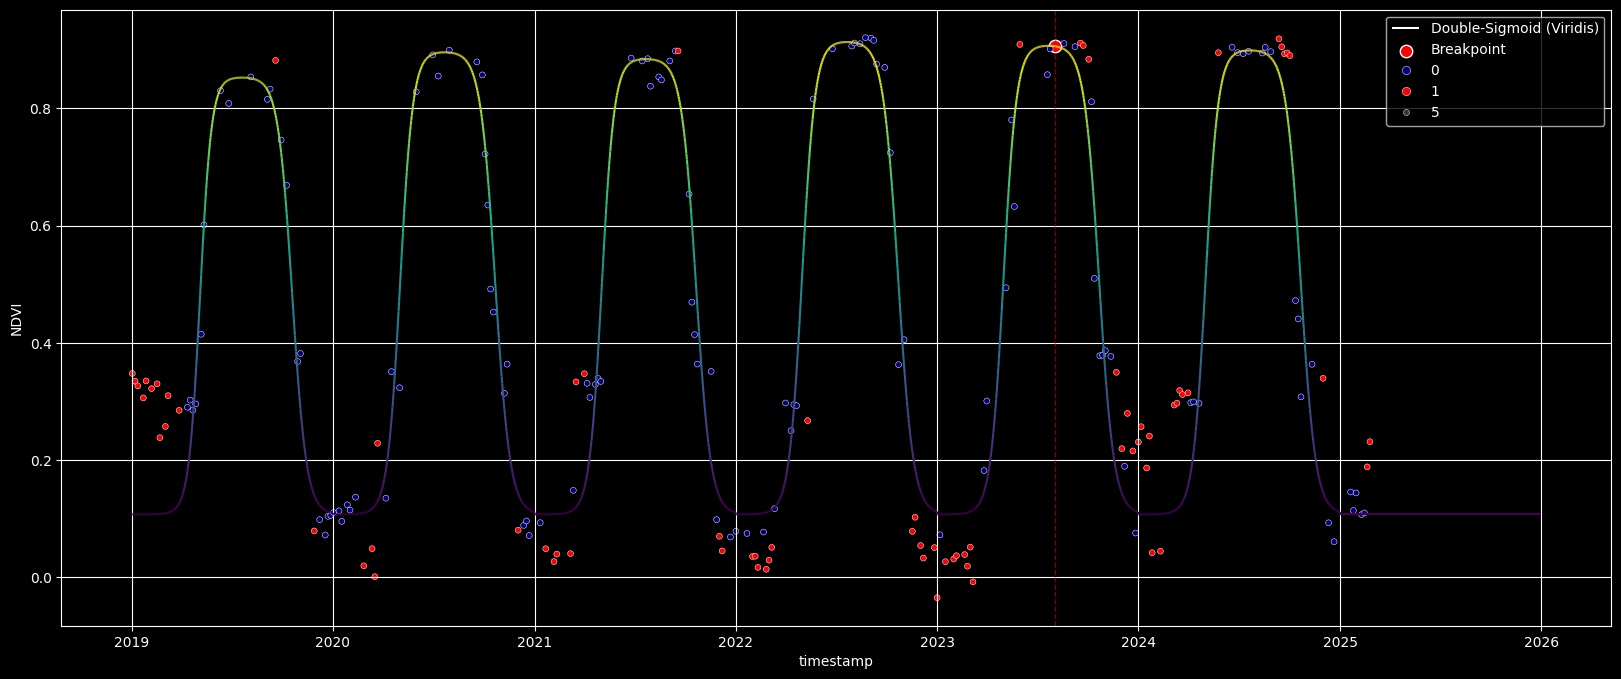

In [106]:
sol.plot_outliers_with_breaks(0.6, 20, 10, 0.15)